Wernicke's data tested with Broca's LV-MAE models (trained on "yes" vs "no" on 9 health participants)

# Clone code

In [1]:
# Visuals
!rm -rf SpeckleAI_Visuals/
!git clone https://github.com/danielrubinsteinishere/SpeckleAI_Visuals.git
import sys
sys.path.append('/content/SpeckleAI_Visuals')

from plots.bar_plots import plot_subject_metrics
from stats.eval import summarize
from cm.binary_cms import plot_binary_confusion_matrix_from_cm, create_image_with_multiple_binary_confusion_matrices, create_image_with_mean_binary_confusion_matrix
from cm.multiclass_cms import display_multiclass_cm_with_percents
from metrics.metrics import macro_F1_from_cm, macro_F1_accuracy_from_cm, calc_mean_acc_and_F1, create_mean_cm

# Models:
!rm -rf SpecklesAI/

#if you are clonning a public version, use:
!git clone https://github.com/natalyasegal/SpecklesAI.git

!cp SpecklesAI/config/config_compehension__N_S_M_P.py SpecklesAI/config/config.py #pay attention to this

import sys
sys.path.append('/content/SpecklesAI')   # add package root to Python path

#from utils.swap import swap_categories
from config.config import binarize_lables, load_yaml, Configuration, Configuration_Minimal
from utils.norm import normalize_per_fixedclip
from utils.swap import *
from utils.stats import print_stats, print_test_stats
from utils.formatstranslator import make_x_per_category, test2trainformat, limit_rearrange_and_flatten_s
from utils.data import split_by_chunks, split_from_start, load_dataset_x, concatenate_train_or_val
from utils.utils import save_dataset_x, save_dataset
from utils.embeddings_utils import concat_temporal_embeddings # sliding window -> target size: N-k+1
from utils.utils_seed import set_seed_all
from preprocessing.preprocessing import unison_shuffled_copies
from pca.pca import visualize_embeddings_pca_3d, reduce_embeddings_pca_3d
from models.LvMAE_pt import VideoMAE
from models.LvMAE_pt import *
from models.binary_XGBoost import train_eval_xgboost_classifier
from models.multiclass_XGBoost import train_eval_xgboost_classifier_multiclass, train_eval_xgb_train_api_multiclass, get_multiclass_cm_with_percents
from models.XGBoost_on_LV_MAE_embeddings import train_and_eval_classifier_on_embeddings, train_and_eval_multiclass_classifier_on_embeddings
from evaluation.eval import calc_accumulated_predictions, generate_confusion_matrix_image, plot_nice_roc_curve, find_optimal_threshold, evaluate_model, evaluate_per_chunk, flatten_accumulated
from evaluation.eval_utils import eval_aggregated_test_set_th_on_val, eval_aggregated_th_on_target_subj_firstK_chunks

set_seed_all(seed_for_init=1, random_seed=9, use_tf = False)

# imports:
from sklearn.metrics import confusion_matrix

Cloning into 'SpeckleAI_Visuals'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 83 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 351.85 KiB | 7.49 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Cloning into 'SpecklesAI'...
remote: Enumerating objects: 1660, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 1660 (delta 117), reused 2 (delta 2), pack-reused 1484 (from 3)
Receiving objects: 100% (1660/1660), 88.44 MiB | 22.44 MiB/s, done.
Resolving deltas: 100% (958/958), done.
[set_seed] All seeds set (seed_for_init=1, random_seed=9).


# Print versions

In [3]:
import sys, platform, torch, torchvision

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

# Core scientific stack
import numpy as np, pandas as pd, matplotlib, sklearn
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


Python version: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
Numpy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91900
XGBoost: 3.4.1
LightGBM: 4.6.0
Transformers: 5.16.1
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91900
XGBoost: 3.4.1
LightGBM: 4.6.0
Transformers: 5.16.1


# Mount

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Raw data

## 2

In [5]:
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_ZEEV.zip

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_ZEEV.zip
   creating: exp3_ZEEV/
   creating: exp3_ZEEV/26112023_day1/
   creating: exp3_ZEEV/26112023_day1/Zeev/
   creating: exp3_ZEEV/26112023_day1/Zeev/Wernike/
   creating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093345191.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093357681.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093409504.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093421143.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093436761.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093448708.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/eng

In [6]:
!ls exp3_ZEEV/26112023_day1/Zeev/Wernike/swedish

acA1440-220um__40034984__20231126_093643373.avi
acA1440-220um__40034984__20231126_093654923.avi
acA1440-220um__40034984__20231126_093706770.avi
acA1440-220um__40034984__20231126_093718835.avi
acA1440-220um__40034984__20231126_093730761.avi
acA1440-220um__40034984__20231126_093743340.avi
acA1440-220um__40034984__20231126_093755099.avi
acA1440-220um__40034984__20231126_093807042.avi
acA1440-220um__40034984__20231126_093818634.avi
acA1440-220um__40034984__20231126_093830171.avi


## 12

In [6]:
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_Wernicke.zip

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_Wernicke.zip
   creating: exp3_9_Daniel_Wernicke/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124115962.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124128724.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124141642.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124154145.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124206882.avi  
  inflating:

# Look as raw frames

## code

In [24]:
!ls exp3_ZEEV/26112023_day1/Zeev/Wernike/mother_tonque

acA1440-220um__40034984__20231126_093943259.avi
acA1440-220um__40034984__20231126_093954926.avi
acA1440-220um__40034984__20231126_094006356.avi
acA1440-220um__40034984__20231126_094052996.avi
acA1440-220um__40034984__20231126_094104709.avi
acA1440-220um__40034984__20231126_094115980.avi
acA1440-220um__40034984__20231126_094127349.avi
acA1440-220um__40034984__20231126_094139198.avi
acA1440-220um__40034984__20231126_094150660.avi
acA1440-220um__40034984__20231126_094202126.avi


In [30]:
!ls exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/mother_tonque

acA1440-220um__40034984__20230605_125431714.avi
acA1440-220um__40034984__20230605_125443585.avi
acA1440-220um__40034984__20230605_125455181.avi
acA1440-220um__40034984__20230605_125506690.avi
acA1440-220um__40034984__20230605_125547009.avi
acA1440-220um__40034984__20230605_125558521.avi
acA1440-220um__40034984__20230605_125611209.avi
acA1440-220um__40034984__20230605_125635295.avi
acA1440-220um__40034984__20230605_125646490.avi
acA1440-220um__40034984__20230605_125658083.avi


Subj12/native: 10 clips | effective Welch window = 10.0 s
Subj12/swedish: 10 clips | effective Welch window = 10.0 s
Subj2/native: 10 clips | effective Welch window = 10.0 s
Subj2/swedish: 10 clips | effective Welch window = 10.0 s

=== condition-level mean ± SD across clips ===
('Subj12', 'native'): intensity_SD = 7.527 ± 4.08 (n=10)
('Subj12', 'native'): frame_corr = 0.8979 ± 0.013 (n=10)
('Subj12', 'native'): flow = 0.5157 ± 0.0752 (n=10)
('Subj12', 'native'): cardiac = 0.01076 ± 0.00617 (n=10)
('Subj12', 'native'): resp = 0.002149 ± 0.00258 (n=10)
('Subj12', 'swedish'): intensity_SD = 15.28 ± 6.74 (n=10)
('Subj12', 'swedish'): frame_corr = 0.8916 ± 0.0118 (n=10)
('Subj12', 'swedish'): flow = 0.5532 ± 0.0639 (n=10)
('Subj12', 'swedish'): cardiac = 0.009738 ± 0.00363 (n=10)
('Subj12', 'swedish'): resp = 0.003307 ± 0.00292 (n=10)
('Subj2', 'native'): intensity_SD = 9.933 ± 2.79 (n=10)
('Subj2', 'native'): frame_corr = 0.8752 ± 0.0273 (n=10)
('Subj2', 'native'): flow = 0.3385 ± 0.0195 

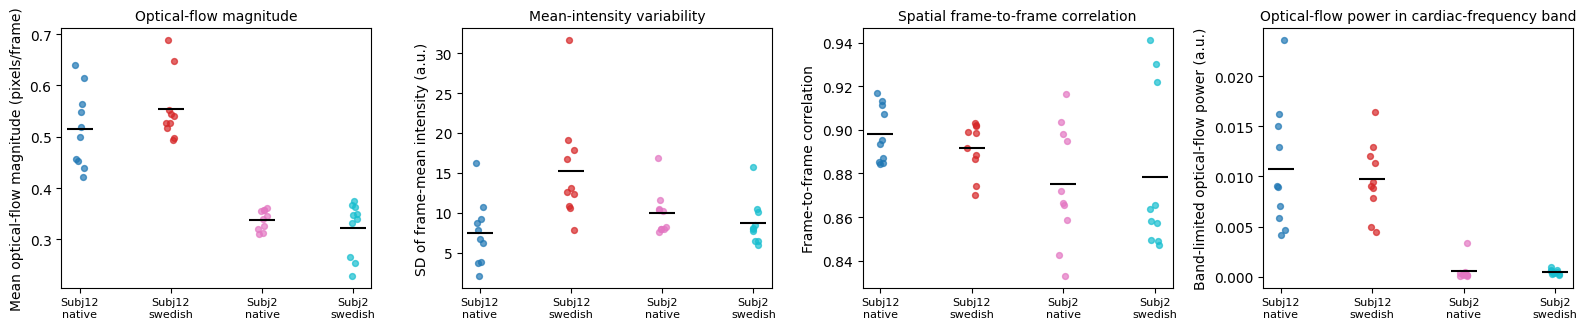

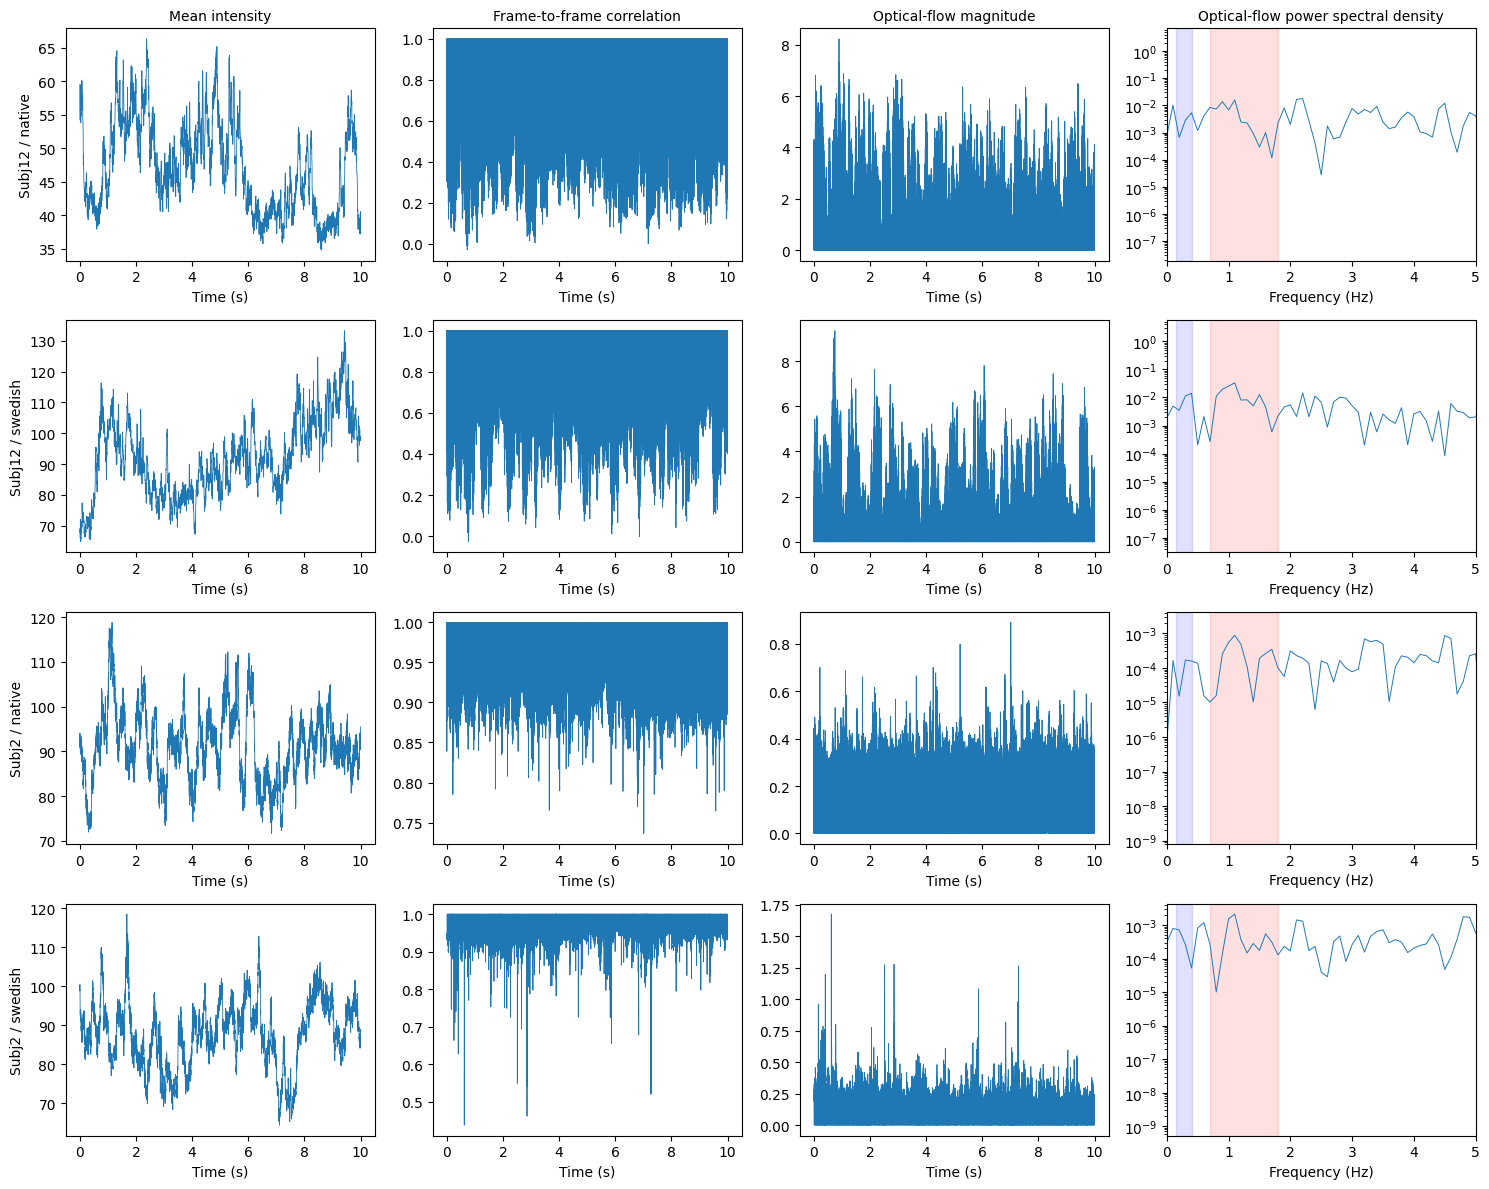


subj   cond     clip                     intSD     ftf    flow   cardiac      resp
Subj12 native   acA1440-220um__40034984__20230605_125431714.avi   6.746   0.887   0.519    0.0059    0.0003
Subj12 native   acA1440-220um__40034984__20230605_125443585.avi   3.693   0.884   0.453    0.0071    0.0001
Subj12 native   acA1440-220um__40034984__20230605_125455181.avi   3.885   0.893   0.457    0.0047    0.0017
Subj12 native   acA1440-220um__40034984__20230605_125506690.avi   7.811   0.885   0.639    0.0041    0.0079
Subj12 native   acA1440-220um__40034984__20230605_125547009.avi   2.109   0.885   0.422    0.0130    0.0006
Subj12 native   acA1440-220um__40034984__20230605_125558521.avi   6.183   0.913   0.438    0.0090    0.0007
Subj12 native   acA1440-220um__40034984__20230605_125611209.avi   8.705   0.911   0.549    0.0236    0.0006
Subj12 native   acA1440-220um__40034984__20230605_125635295.avi   9.173   0.907   0.564    0.0150    0.0020
Subj12 native   acA1440-220um__40034984__20230605_12

In [31]:
import os, glob
import numpy as np
import cv2
from scipy.signal import welch
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Raw-signal characterization of native-resolution speckle videos
# (answers Reviewer Major_3: show and characterize the original optical data)
# ----------------------------------------------------------------------

FPS      = 1000.0                 # native acquisition rate (1 kHz) — important
WELCH_S  = 10                     # Welch window = min(10 s, clip length)
CARDIAC  = (0.7, 1.8)             # cardiac band (Hz)  ~42–108 bpm
RESP     = (0.15, 0.4)            # respiratory band (Hz) ~9–24 /min
MAX_CLIPS = None                  # None = use ALL clips per condition (variability panel)
LIMIT     = None                  # None = use full clip length; else cap frames per clip

# (subject, condition) -> directory of native-resolution .avi clips
DIRS = {
    ("Subj12", "native"):  "exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/mother_tonque",
    ("Subj12", "swedish"): "exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/swedish",
    ("Subj2",  "native"):  "exp3_ZEEV/26112023_day1/Zeev/Wernike/mother_tonque",
    ("Subj2",  "swedish"): "exp3_ZEEV/26112023_day1/Zeev/Wernike/swedish",   # <-- confirm Zeev's Swedish path
}

PATTERN = "*.avi"


def load_frames(path, max_frames=None):
    """Load a native-resolution speckle clip as (T, H, W) float32.
    Source is grayscale; OpenCV may decode it as 3 identical BGR channels,
    so take channel 0 directly (no color conversion, no resize)."""
    cap = cv2.VideoCapture(path)
    out = []
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        gray = fr[:, :, 0] if fr.ndim == 3 else fr
        out.append(gray.astype(np.float32))
        if max_frames is not None and len(out) >= max_frames:
            break
    cap.release()
    return np.asarray(out)


def characterize(frames):
    T = len(frames)
    if T < 3:
        raise ValueError("Too few frames for characterization.")

    # Frame-mean luminance per frame (its temporal SD is reported below)
    mean_int = frames.mean(axis=(1, 2))

    # Spatial Pearson correlation between consecutive frames
    x = frames.reshape(T, -1)
    x = x - x.mean(axis=1, keepdims=True)
    num = (x[1:] * x[:-1]).sum(axis=1)
    den = np.sqrt((x[1:] ** 2).sum(axis=1) * (x[:-1] ** 2).sum(axis=1)) + 1e-9
    ftf_corr = num / den

    # Mean dense optical-flow magnitude (Farnebäck; requires 8-bit input)
    flow = np.empty(T - 1, dtype=np.float32)
    for t in range(T - 1):
        a = frames[t].astype(np.uint8)
        b = frames[t + 1].astype(np.uint8)
        fl = cv2.calcOpticalFlowFarneback(a, b, None,
                                          0.5, 3, 15, 3, 5, 1.2, 0)
        flow[t] = np.sqrt(fl[..., 0] ** 2 + fl[..., 1] ** 2).mean()

    # Welch PSD of the flow trace; window capped by available clip length
    nperseg = min(int(WELCH_S * FPS), len(flow))
    fpf, pxf = welch(flow, fs=FPS, nperseg=nperseg, detrend="constant")

    def band_power(lo, hi):
        # integrate PSD over the band (× Δf) -> band-limited power
        mask = (fpf >= lo) & (fpf < hi)
        df = fpf[1] - fpf[0]
        return float(np.sum(pxf[mask]) * df)

    return dict(
        mean_int=mean_int, ftf_corr=ftf_corr, flow=flow,
        fpf=fpf, pxf=pxf, T=T, nperseg=nperseg,
        summ=dict(
            int_SD=float(mean_int.std()),   # temporal SD of frame-mean intensity
            ftf=float(ftf_corr.mean()),
            flow=float(flow.mean()),
            cardiac=band_power(*CARDIAC),
            resp=band_power(*RESP),
        ),
    )


# ----------------------------------------------------------------------
# Run over all clips; keep the first clip per condition for the trace figure
# ----------------------------------------------------------------------
rows, example = [], {}
for (subj, cond), d in DIRS.items():
    paths = sorted(glob.glob(os.path.join(d, PATTERN)))
    if MAX_CLIPS is not None:
        paths = paths[:MAX_CLIPS]
    if not paths:
        print(f"[warn] no clips for {subj}/{cond}: {d}")
        continue
    for i, p in enumerate(paths):
        frames = load_frames(p, max_frames=LIMIT)
        c = characterize(frames)
        s = c["summ"]
        rows.append((subj, cond, os.path.basename(p),
                     s["int_SD"], s["ftf"], s["flow"], s["cardiac"], s["resp"]))
        if i == 0:                       # first clip per condition -> trace panel
            example[(subj, cond)] = c
    eff = example[(subj, cond)]["nperseg"] / FPS
    print(f"{subj}/{cond}: {len(paths)} clips | effective Welch window = {eff:.1f} s")

# ----------------------------------------------------------------------
# Condition-level mean ± SD across clips (Major_3: within/between-condition)
# ----------------------------------------------------------------------
labels = sorted({(r[0], r[1]) for r in rows})
metric_idx = {
    "intensity_SD": 3,
    "frame_corr":   4,
    "flow":         5,
    "cardiac":      6,
    "resp":         7,
}

print("\n=== condition-level mean ± SD across clips ===")
for lab in labels:
    rr = [r for r in rows if (r[0], r[1]) == lab]
    for name, idx in metric_idx.items():
        v = np.asarray([r[idx] for r in rr], dtype=float)
        sd = v.std(ddof=1) if len(v) > 1 else np.nan
        print(f"{lab}: {name} = {v.mean():.4g} ± {sd:.3g} (n={len(v)})")

# ----------------------------------------------------------------------
# Figure 1 — 4-panel within-condition variability across ALL clips (+ mean bars)
# ----------------------------------------------------------------------
rng = np.random.default_rng(0)    # seeded jitter (graphical only, reproducible)
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
cmap = {lab: colors[i] for i, lab in enumerate(labels)}

panels = [
    (5, "Mean optical-flow magnitude (pixels/frame)", "Optical-flow magnitude"),
    (3, "SD of frame-mean intensity (a.u.)",          "Mean-intensity variability"),
    (4, "Frame-to-frame correlation",                 "Spatial frame-to-frame correlation"),
    (6, "Band-limited optical-flow power (a.u.)",     "Optical-flow power in cardiac-frequency band"),
]
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a, (idx, yl, ttl) in zip(ax, panels):
    for r in rows:
        lab = (r[0], r[1])
        xj = labels.index(lab) + rng.uniform(-0.05, 0.05)
        a.scatter(xj, r[idx], color=cmap[lab], s=18, alpha=0.7)
    for j, lab in enumerate(labels):
        vals = np.asarray([r[idx] for r in rows if (r[0], r[1]) == lab])
        a.scatter([j], [vals.mean()], marker="_", s=350, c="k", zorder=5)
    a.set_title(ttl, fontsize=10)
    a.set_ylabel(yl)
    a.set_xticks(range(len(labels)))
    a.set_xticklabels([f"{s}\n{c}" for s, c in labels], fontsize=8)

fig.tight_layout()
fig.savefig("Sup_variability.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------------
# Figure 2 — example traces from the first clip per condition
# ----------------------------------------------------------------------
keys = list(example.keys())
fig, axes = plt.subplots(len(keys), 4, figsize=(15, 3.0 * len(keys)))
if len(keys) == 1:
    axes = axes[None, :]

titles = ["Mean intensity", "Frame-to-frame correlation",
          "Optical-flow magnitude", "Optical-flow power spectral density"]
for j, key in enumerate(keys):
    c = example[key]
    t_int  = np.arange(c["T"]) / FPS
    t_flow = np.arange(c["T"] - 1) / FPS

    axes[j, 0].plot(t_int,  c["mean_int"], lw=0.6)
    axes[j, 1].plot(t_flow, c["ftf_corr"], lw=0.6)
    axes[j, 2].plot(t_flow, c["flow"],     lw=0.6)
    axes[j, 3].semilogy(c["fpf"], c["pxf"], lw=0.7)
    axes[j, 3].axvspan(*CARDIAC, color="red",  alpha=0.12)
    axes[j, 3].axvspan(*RESP,    color="blue", alpha=0.12)
    axes[j, 3].set_xlim(0, 5)

    axes[j, 0].set_ylabel(f"{key[0]} / {key[1]}")
    for k in range(3):
        axes[j, k].set_xlabel("Time (s)")
    axes[j, 3].set_xlabel("Frequency (Hz)")
    if j == 0:
        for k, ttl in enumerate(titles):
            axes[j, k].set_title(ttl, fontsize=10)

fig.tight_layout()
fig.savefig("Sup_raw_traces.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------------
# Per-clip summary table
# ----------------------------------------------------------------------
print(f"\n{'subj':7s}{'cond':9s}{'clip':22s}"
      f"{'intSD':>8s}{'ftf':>8s}{'flow':>8s}{'cardiac':>10s}{'resp':>10s}")
for r in rows:
    print(f"{r[0]:7s}{r[1]:9s}{r[2]:22s}"
          f"{r[3]:8.3f}{r[4]:8.3f}{r[5]:8.3f}{r[6]:10.4f}{r[7]:10.4f}")

### try - old version

Welch nperseg=10000 samples (10.00 s), frequency resolution=0.100 Hz
('Subj12', 'native') | acA1440-220um__40034984__20230605_134509709.avi: {'int_SD': 4.545552730560303, 'ftf': 0.8895491361618042, 'flow': 0.4755985736846924, 'cardiac': 0.06923308968544006, 'resp': 0.01332140900194645}
('Subj12', 'native') | acA1440-220um__40034984__20230605_134521471.avi: {'int_SD': 6.57628870010376, 'ftf': 0.8987771272659302, 'flow': 0.42936795949935913, 'cardiac': 0.06793928891420364, 'resp': 0.007964253425598145}
('Subj12', 'native') | acA1440-220um__40034984__20230605_134535459.avi: {'int_SD': 6.105857849121094, 'ftf': 0.9220147728919983, 'flow': 0.4268442988395691, 'cardiac': 0.13938619196414948, 'resp': 0.0024844841100275517}
('Subj12', 'swedish') | acA1440-220um__40034984__20230605_124540457.avi: {'int_SD': 12.380593299865723, 'ftf': 0.9020943641662598, 'flow': 0.49758604168891907, 'cardiac': 0.128932923078537, 'resp': 0.01474200002849102}
('Subj12', 'swedish') | acA1440-220um__40034984__202306

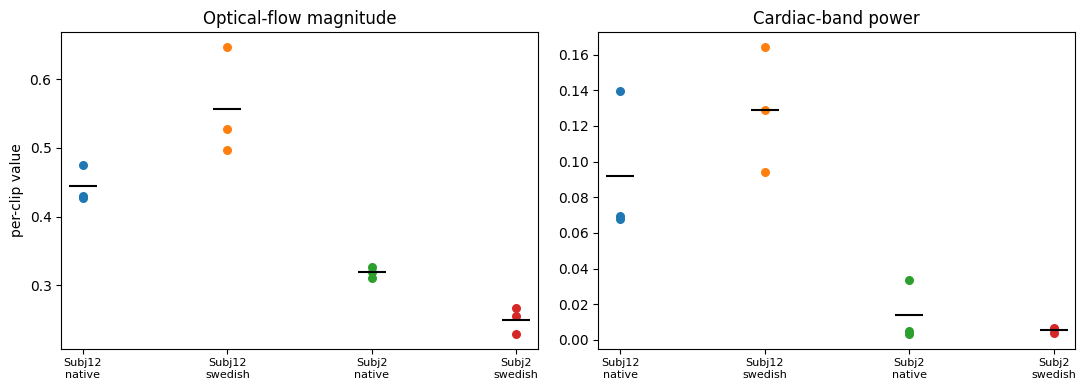

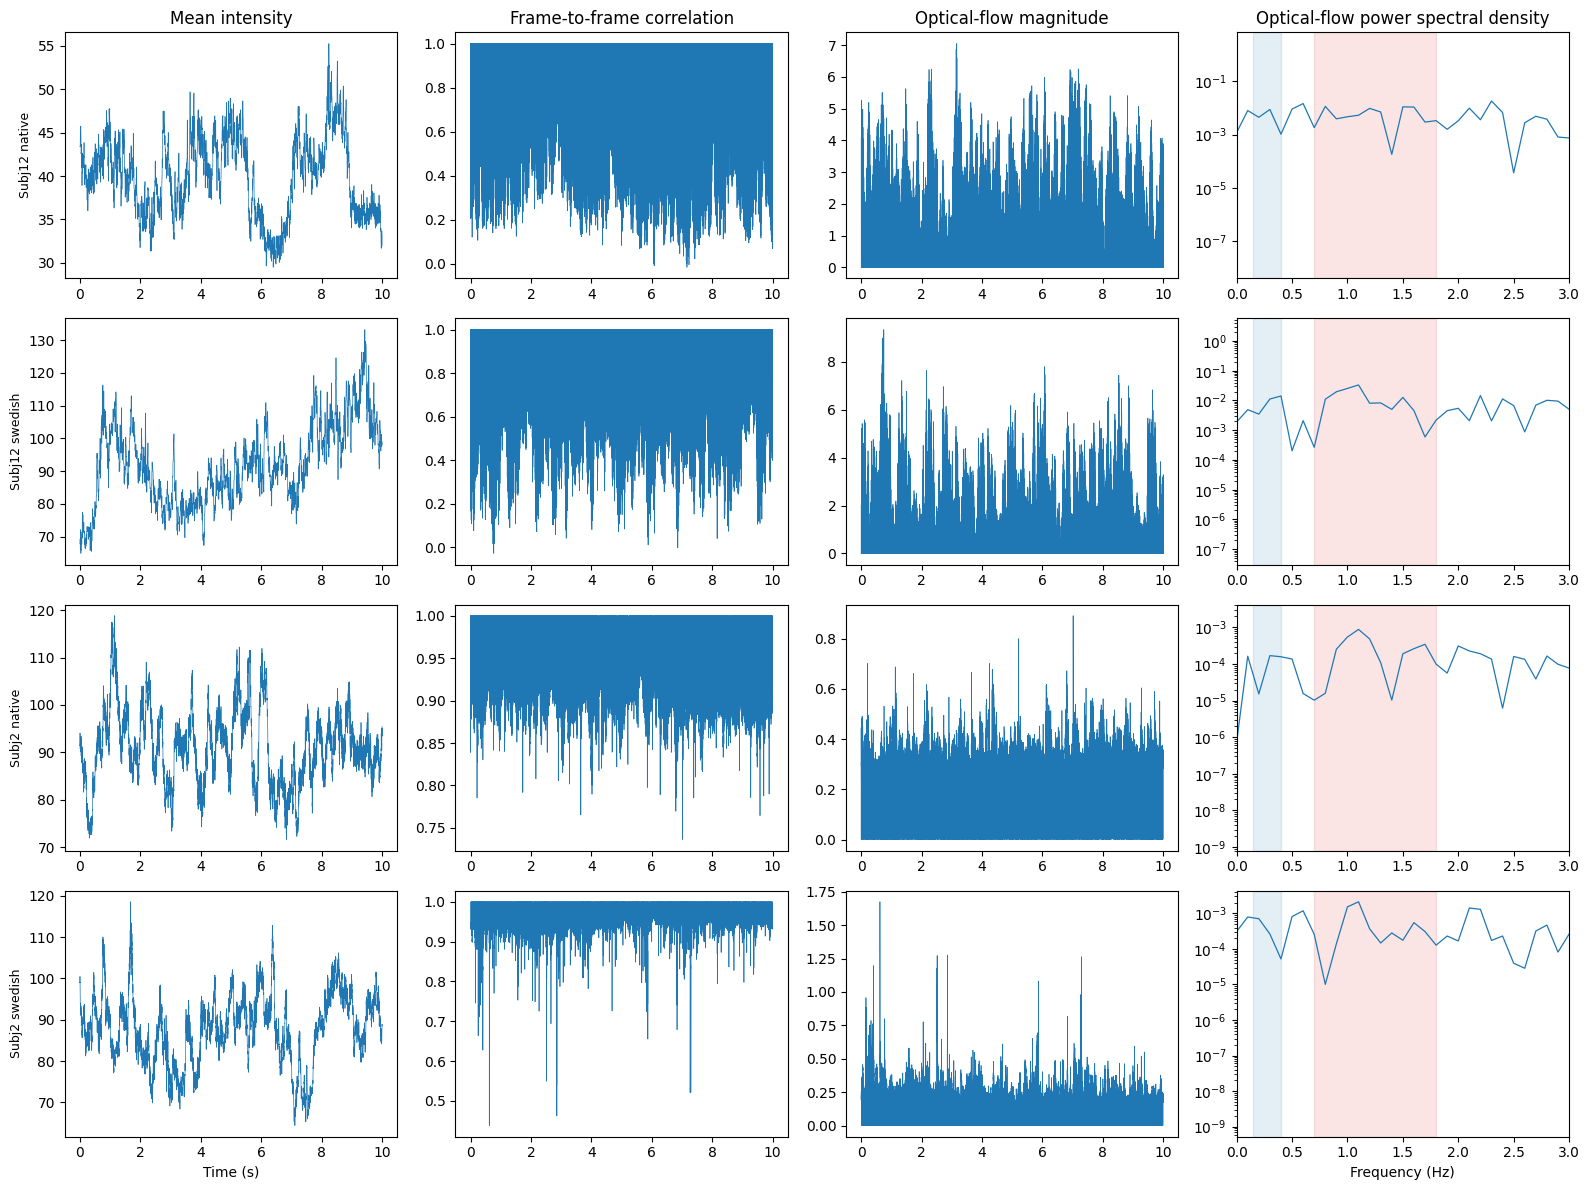

saved: Sup_variability.png, Sup_raw_characterization.png


In [17]:
# ============================================================
# Raw-signal characterization, multi-clip per condition — Reviewer Major_3
# Native 128x64 luma, pre-downsample / pre-normalization.
# Spectra use TRUE 1000 fps; Welch window = min(20 s, clip length) ~ 10 s here.
# ============================================================
import cv2, glob, os, numpy as np, matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------- PARAMETERS -------------------
ROOT   = ""          # optional base/mount prefix, e.g. "gdrive/MyDrive/.../data"
DIRS = {
 ("Subj12","native"):  "exp3_9_Daniel_Wernicke/5062023_day3/Daniel/Wernike/mother_tonque",
 ("Subj12","swedish"): "exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/swedish",
 ("Subj2","native"):   "exp3_ZEEV/26112023_day1/Zeev/Wernike/mother_tonque",
 ("Subj2","swedish"):  "exp3_ZEEV/26112023_day1/Zeev/Wernike/swedish",   # <-- Zeev's swedish dir
}
PATTERN   = "*.avi"
MAX_CLIPS = 3
LIMIT     = None         # None = use full clip (~10 s); or set a frame cap
FPS       = 1000.0       # TRUE acquisition rate
WELCH_S   = 10           # requested Welch window (s); capped at clip length
CARDIAC   = (0.7, 1.8)   # Hz
RESP      = (0.15, 0.4)  # Hz
# --------------------------------------------------

def load_frames(path, max_frames=None):
    cap = cv2.VideoCapture(path); out = []
    while True:
        ok, fr = cap.read()
        if not ok: break
        out.append(cv2.cvtColor(fr, cv2.COLOR_RGB2YUV)[:, :, 0].astype(np.float32))  # luma
        if max_frames and len(out) >= max_frames: break
    cap.release()
    return np.asarray(out)                                   # (T, 64, 128)

def characterize(frames):
    T = len(frames)
    mean_int = frames.mean(axis=(1, 2))
    f = frames.reshape(T, -1); f = f - f.mean(1, keepdims=True)
    num = (f[1:]*f[:-1]).sum(1); den = np.sqrt((f[1:]**2).sum(1)*(f[:-1]**2).sum(1)) + 1e-9
    ftf_corr = num/den
    flow = np.empty(T-1, np.float32)
    for t in range(T-1):
        a = frames[t].astype(np.uint8); b = frames[t+1].astype(np.uint8)   # Farneback needs uint8
        fl = cv2.calcOpticalFlowFarneback(a, b, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        flow[t] = np.sqrt(fl[..., 0]**2 + fl[..., 1]**2).mean()
    nperseg = min(int(WELCH_S*FPS), len(flow))                # window capped at clip length (~10 s)
    fpf, pxf = welch(flow - flow.mean(), fs=FPS, nperseg=nperseg)
    bp = lambda lo, hi: float(pxf[(fpf >= lo) & (fpf < hi)].sum())
    return dict(mean_int=mean_int, ftf_corr=ftf_corr, flow=flow, fpf=fpf, pxf=pxf, T=T, nperseg=nperseg,
                summ=dict(int_SD=float(mean_int.std()), ftf=float(ftf_corr.mean()),
                          flow=float(flow.mean()), cardiac=bp(*CARDIAC), resp=bp(*RESP)))

# ---- run ----
per_clip = {}; example = {}; printed_res = False
for key, d in DIRS.items():
    paths = sorted(glob.glob(os.path.join(ROOT, d, PATTERN)))[:MAX_CLIPS]
    if not paths:
        print("!! no files in", os.path.join(ROOT, d)); continue
    rows = []
    for p in paths:
        fps_tag = cv2.VideoCapture(p).get(cv2.CAP_PROP_FPS)
        if fps_tag not in (0.0, FPS):
            print(f"   note: {os.path.basename(p)} container fps={fps_tag} (ignored; using {FPS})")
        r = characterize(load_frames(p, LIMIT)); rows.append(r['summ'])
        if not printed_res:
            print(f"Welch nperseg={r['nperseg']} samples ({r['nperseg']/FPS:.2f} s), "
                  f"frequency resolution={FPS/r['nperseg']:.3f} Hz"); printed_res = True
        if key not in example: example[key] = r
        print(f"{key} | {os.path.basename(p)}: {r['summ']}")
    per_clip[key] = rows

# ---- within-condition mean ± SD across clips ----
print("\n=== within-condition mean ± SD across clips ===")
for key, rows in per_clip.items():
    for m in ['flow', 'cardiac', 'resp', 'int_SD', 'ftf']:
        v = np.array([x[m] for x in rows]); sd = v.std(ddof=1) if len(v) > 1 else 0.0
        print(f"{key} {m}: {v.mean():.4g} ± {sd:.2g} (n={len(v)})")

# ---- figure 1: within/between-condition variability ----
keys = list(per_clip.keys())
fig, axv = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, ttl in [(axv[0], 'flow', 'Optical-flow magnitude'),
                        (axv[1], 'cardiac', 'Cardiac-band power')]:
    for j, key in enumerate(keys):
        vals = [x[metric] for x in per_clip[key]]
        ax.scatter([j]*len(vals), vals, s=30); ax.scatter([j], [np.mean(vals)], marker='_', s=400, c='k')
    ax.set_xticks(range(len(keys))); ax.set_xticklabels([f"{s}\n{c}" for s, c in keys], fontsize=8)
    ax.set_title(ttl)
axv[0].set_ylabel("per-clip value"); plt.tight_layout()
plt.savefig("Sup_variability.png", dpi=150); plt.show()

# ---- figure 2: example traces + optical-flow PSD (one clip per condition) ----
t = lambda n: np.arange(n)/FPS
fig, ax = plt.subplots(len(example), 4, figsize=(16, 3*len(example)))
if len(example) == 1: ax = ax[None, :]
for i, (key, r) in enumerate(example.items()):
    ax[i,0].plot(t(r['T']),   r['mean_int'], lw=.5); ax[i,0].set_ylabel(f"{key[0]} {key[1]}", fontsize=9)
    ax[i,1].plot(t(r['T']-1), r['ftf_corr'], lw=.5)
    ax[i,2].plot(t(r['T']-1), r['flow'],     lw=.5)
    ax[i,3].semilogy(r['fpf'], r['pxf'], lw=.9); ax[i,3].set_xlim(0, 3)
    ax[i,3].axvspan(*CARDIAC, color='tab:red',  alpha=.12)
    ax[i,3].axvspan(*RESP,    color='tab:blue', alpha=.12)
for j, ttl in enumerate(["Mean intensity", "Frame-to-frame correlation",
                        "Optical-flow magnitude", "Optical-flow power spectral density"]):
    ax[0, j].set_title(ttl)
ax[-1,0].set_xlabel("Time (s)"); ax[-1,3].set_xlabel("Frequency (Hz)")
plt.tight_layout(); plt.savefig("Sup_raw_characterization.png", dpi=150); plt.show()
print("saved: Sup_variability.png, Sup_raw_characterization.png")

# Illustrations

Subj12 Native  clip 1: acA1440-220um__40034984__20230605_134509709.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj12 Native  clip 2: acA1440-220um__40034984__20230605_134521471.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj12 Swedish clip 1: acA1440-220um__40034984__20230605_124540457.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj12 Swedish clip 2: acA1440-220um__40034984__20230605_124604370.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj2  Native  clip 1: acA1440-220um__40034984__20231126_093943259.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj2  Native  clip 2: acA1440-220um__40034984__20231126_093954926.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj2  Swedish clip 1: acA1440-220um__40034984__20231126_093643373.avi | raw=(64, 128), processed=(32, 32), processed range=[0.000, 10.000]
Subj2  Swedish clip 

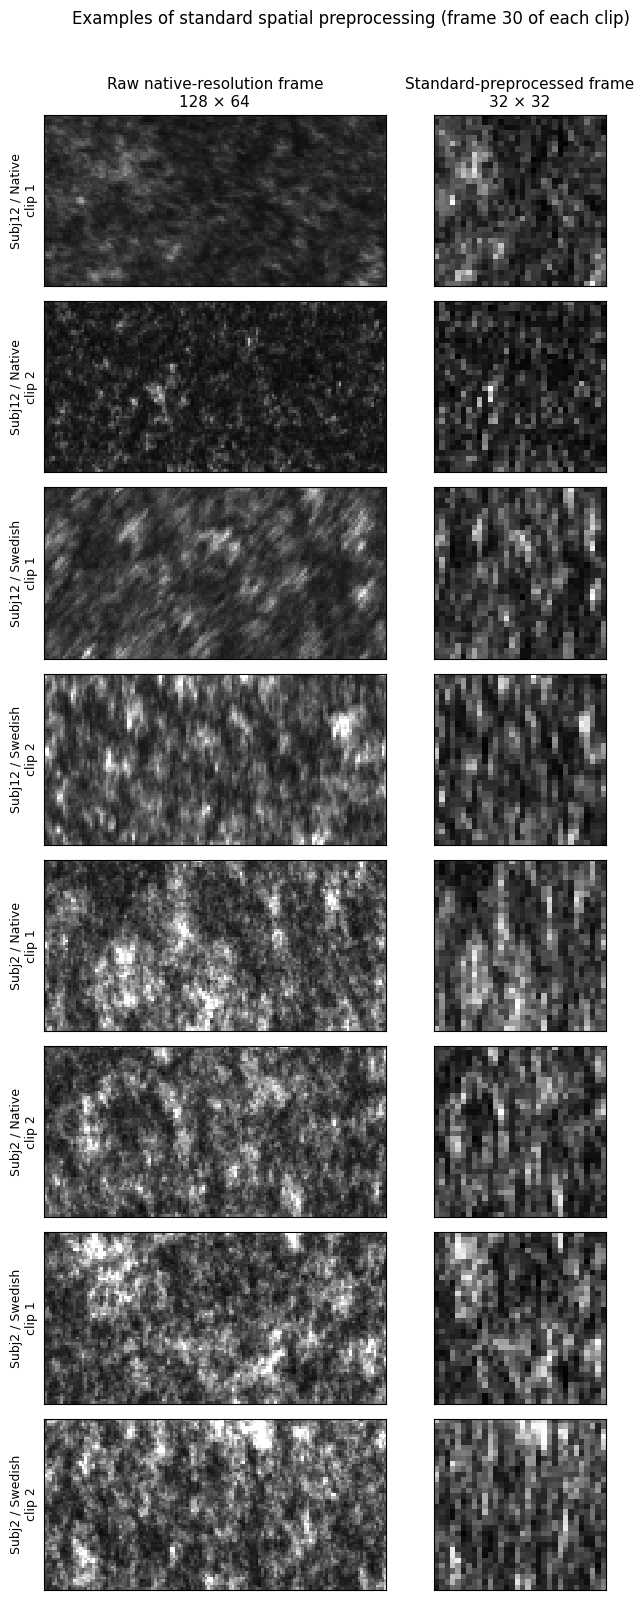


Saved: preprocessing_examples/Sup_raw_to_preprocessed_examples.png


In [9]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Raw 128x64 -> standard preprocessed 32x32 examples
#
# 8 clips total:
#   Subject 12: 2 Native + 2 Swedish
#   Subject 2 : 2 Native + 2 Swedish
#
# For each clip:
#   - take frame 20 = center of the first 40-frame input window
#   - preserve native 128x64 grayscale frame
#   - apply standard spatial preprocessing:
#         resize -> 32x32
#         min-max normalization over X,Y
#         gain x10
# ============================================================

ROOT = ""

DIRS = {
    ("Subj12", "Native"):
        "exp3_9_Daniel_Wernicke/5062023_day3/Daniel/Wernike/mother_tonque",

    ("Subj12", "Swedish"):
        "exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/swedish",

    ("Subj2", "Native"):
        "exp3_ZEEV/26112023_day1/Zeev/Wernike/mother_tonque",

    ("Subj2", "Swedish"):
        "exp3_ZEEV/26112023_day1/Zeev/Wernike/swedish",
}

PATTERN = "*.avi"

N_CLIPS_PER_CONDITION = 2
FRAME_IDX = 30              # centre frame of first 40-frame window

TARGET_H = 32
TARGET_W = 32
GAIN = 10.0

OUTDIR = "preprocessing_examples"
os.makedirs(OUTDIR, exist_ok=True)


# ------------------------------------------------------------
# Read one native grayscale frame
# ------------------------------------------------------------
def read_gray_frame(path, frame_idx):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        raise RuntimeError(f"Could not open: {path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(
            f"Could not read frame {frame_idx} from {path}"
        )

    # Source recordings are grayscale.
    # OpenCV can nevertheless decode AVI as three identical channels.
    gray = frame[:, :, 0] if frame.ndim == 3 else frame

    return gray


# ------------------------------------------------------------
# Standard frame preprocessing
# ------------------------------------------------------------
def standard_preprocess_frame(gray):
    """
    Native grayscale frame -> 32x32 model-space frame.

    1. Spatial resize to 32x32.
    2. Min-max normalization over spatial dimensions X,Y.
    3. Gain x10.
    """

    # OpenCV default interpolation is INTER_LINEAR
    resized = cv2.resize(
        gray,
        (TARGET_W, TARGET_H),
        interpolation=cv2.INTER_LINEAR,
    ).astype(np.float32)

    mn = resized.min()
    mx = resized.max()

    if mx > mn:
        processed = (resized - mn) / (mx - mn)
    else:
        processed = np.zeros_like(resized, dtype=np.float32)

    processed *= GAIN

    return resized, processed


# ------------------------------------------------------------
# Collect exactly 8 examples
# ------------------------------------------------------------
examples = []

for (subj, condition), directory in DIRS.items():

    full_dir = os.path.join(ROOT, directory)
    paths = sorted(glob.glob(os.path.join(full_dir, PATTERN)))

    if len(paths) < N_CLIPS_PER_CONDITION:
        raise RuntimeError(
            f"{subj}/{condition}: expected at least "
            f"{N_CLIPS_PER_CONDITION} clips, found {len(paths)} "
            f"in {full_dir}"
        )

    # Deterministic: first two alphabetically/time-sorted clips
    paths = paths[:N_CLIPS_PER_CONDITION]

    for clip_no, path in enumerate(paths, start=1):

        raw = read_gray_frame(path, FRAME_IDX)

        if raw.shape != (64, 128):
            print(
                f"[warning] {os.path.basename(path)}: "
                f"expected native shape (64,128), got {raw.shape}"
            )

        resized, processed = standard_preprocess_frame(raw)

        examples.append({
            "subject": subj,
            "condition": condition,
            "clip_no": clip_no,
            "filename": os.path.basename(path),
            "raw": raw,
            "resized": resized,
            "processed": processed,
        })

        print(
            f"{subj:6s} {condition:7s} clip {clip_no}: "
            f"{os.path.basename(path)} | "
            f"raw={raw.shape}, processed={processed.shape}, "
            f"processed range="
            f"[{processed.min():.3f}, {processed.max():.3f}]"
        )


assert len(examples) == 8, f"Expected 8 examples, got {len(examples)}"


# ============================================================
# Save exact arrays and individual images
# ============================================================
for ex in examples:

    stem = (
        f"{ex['subject']}_{ex['condition']}_"
        f"clip{ex['clip_no']}_frame{FRAME_IDX}"
    )

    # Exact native grayscale image
    cv2.imwrite(
        os.path.join(OUTDIR, stem + "_raw_128x64.png"),
        ex["raw"],
    )

    # Exact numeric processed 32x32 array
    np.save(
        os.path.join(OUTDIR, stem + "_processed_32x32.npy"),
        ex["processed"],
    )

    # Display PNG only:
    # convert [0,10] -> [0,255] without changing the saved numeric array
    disp = np.clip(
        ex["processed"] / GAIN * 255.0,
        0,
        255
    ).astype(np.uint8)

    # Keep file intrinsically 32x32
    cv2.imwrite(
        os.path.join(OUTDIR, stem + "_processed_32x32.png"),
        disp,
    )


# ============================================================
# Supplementary figure:
# 8 rows x 2 columns
# Raw native frame | Standard-preprocessed frame
# ============================================================
fig, axes = plt.subplots(
    len(examples),
    2,
    figsize=(7.2, 2.0 * len(examples))
)

for i, ex in enumerate(examples):

    # Raw 128x64
    axes[i, 0].imshow(
        ex["raw"],
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest",
        aspect="equal",
    )

    # Exact processed values displayed with fixed 0..10 scale
    axes[i, 1].imshow(
        ex["processed"],
        cmap="gray",
        vmin=0,
        vmax=GAIN,
        interpolation="nearest",
        aspect="equal",
    )

    axes[i, 0].set_ylabel(
        f"{ex['subject']} / {ex['condition']}\n"
        f"clip {ex['clip_no']}",
        fontsize=9,
    )

    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])

axes[0, 0].set_title(
    "Raw native-resolution frame\n128 × 64",
    fontsize=11,
)

axes[0, 1].set_title(
    "Standard-preprocessed frame\n32 × 32",
    fontsize=11,
)

fig.suptitle(
    f"Examples of standard spatial preprocessing "
    f"(frame {FRAME_IDX} of each clip)",
    fontsize=12,
    y=0.997,
)

fig.tight_layout(rect=[0, 0, 1, 0.985])

fig.savefig(
    os.path.join(OUTDIR, "Sup_raw_to_preprocessed_examples.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSaved:",
    os.path.join(
        OUTDIR,
        "Sup_raw_to_preprocessed_examples.png"
    )
)

# Create datasets
- just for reference here

## code

In [7]:
def normalize_40ms(X, n_chunks_per_clip, mode, gain):
    orig_shape = X.shape
    return normalize_per_fixedclip(
        X.reshape(-1, 40, 32, 32, 1),
        n_chunks_per_clip=n_chunks_per_clip,
        mode=mode,
        gain=gain
    ).reshape(orig_shape)

## copy npys from drive

In [8]:
!cp gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_N_S_M_P/morning/*.npy .
!cp gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_N_E_S_M_P/morning/*.npy .
!ls -l

total 6990128
drwxr-xr-x  5 root root       4096 Jun  5  2023 exp3_9_Daniel_Wernicke
drwxr-xr-x  3 root root       4096 Nov 26  2023 exp3_ZEEV
drwx------  5 root root       4096 Sep 28 12:57 gdrive
drwxr-xr-x  1 root root       4096 Sep  4 13:32 sample_data
drwxr-xr-x  8 root root       4096 Sep 28 12:56 SpeckleAI_Visuals
drwxr-xr-x 12 root root       4096 Sep 28 12:57 SpecklesAI
-rw-------  1 root root  245760128 Sep 28 13:00 test_compr4_per_category_split_morning__14.npy
-rw-------  1 root root  512000128 Sep 28 13:00 test_compr5_per_category_split_morning__10.npy
-rw-------  1 root root  512000128 Sep 28 13:00 test_compr5_per_category_split_morning__11.npy
-rw-------  1 root root  512000128 Sep 28 13:00 test_compr5_per_category_split_morning__12.npy
-rw-------  1 root root  512000128 Sep 28 13:01 test_compr5_per_category_split_morning__13.npy
-rw-------  1 root root  256000128 Sep 28 13:01 test_compr5_per_category_split_morning__1.npy
-rw-------  1 root root  512000128 Sep 28 13:01 

## test format

### morning

In [9]:
#morning
test_norm_on = False # change if needed

test_1_m = load_dataset_x("test_compr5_per_category_split_morning__1.npy", with_normalization = test_norm_on)
test_2_m = load_dataset_x("test_compr5_per_category_split_morning__2.npy", with_normalization = test_norm_on)
test_3_m = load_dataset_x("test_compr5_per_category_split_morning__3.npy", with_normalization = test_norm_on)
test_4_m = load_dataset_x("test_compr5_per_category_split_morning__4.npy", with_normalization = test_norm_on)
test_5_m = load_dataset_x("test_compr5_per_category_split_morning__5.npy", with_normalization = test_norm_on)
test_6_m = load_dataset_x("test_compr5_per_category_split_morning__6.npy", with_normalization = test_norm_on)
test_7_m = load_dataset_x("test_compr5_per_category_split_morning__7.npy", with_normalization = test_norm_on)
test_8_m = load_dataset_x("test_compr5_per_category_split_morning__8.npy", with_normalization = test_norm_on)
test_9_m = load_dataset_x("test_compr5_per_category_split_morning__9.npy", with_normalization = test_norm_on)
test_10_m = load_dataset_x("test_compr5_per_category_split_morning__10.npy", with_normalization = test_norm_on)
test_11_m = load_dataset_x("test_compr5_per_category_split_morning__11.npy", with_normalization = test_norm_on)
test_12_m = load_dataset_x("test_compr5_per_category_split_morning__12.npy", with_normalization = test_norm_on)
test_13_m = load_dataset_x("test_compr5_per_category_split_morning__13.npy", with_normalization = test_norm_on)

test_14_m = load_dataset_x("test_compr4_per_category_split_morning__14.npy", with_normalization = test_norm_on)


Loading test_compr5_per_category_split_morning__1.npy
Loading test_compr5_per_category_split_morning__2.npy
Loading test_compr5_per_category_split_morning__3.npy
Loading test_compr5_per_category_split_morning__4.npy
Loading test_compr5_per_category_split_morning__5.npy
Loading test_compr5_per_category_split_morning__6.npy
Loading test_compr5_per_category_split_morning__7.npy
Loading test_compr5_per_category_split_morning__8.npy
Loading test_compr5_per_category_split_morning__9.npy
Loading test_compr5_per_category_split_morning__10.npy
Loading test_compr5_per_category_split_morning__11.npy
Loading test_compr5_per_category_split_morning__12.npy
Loading test_compr5_per_category_split_morning__13.npy
Loading test_compr4_per_category_split_morning__14.npy


#### norm + gain and train / val format
- just formats, not dividing into sets yet

##### n_chunks_per_clip = 1

In [10]:
norm_mode = "minmax"
gain = 10.0
n_chunks_per_clip = 1 # 1 means that one 40-frame chunk is used as a normalization clip


test_1_m_n_40ms = normalize_40ms(test_1_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_2_m_n_40ms = normalize_40ms(test_2_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_3_m_n_40ms = normalize_40ms(test_3_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_4_m_n_40ms = normalize_40ms(test_4_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_5_m_n_40ms = normalize_40ms(test_5_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_6_m_n_40ms = normalize_40ms(test_6_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_7_m_n_40ms = normalize_40ms(test_7_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_8_m_n_40ms = normalize_40ms(test_8_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_9_m_n_40ms = normalize_40ms(test_9_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_10_m_n_40ms = normalize_40ms(test_10_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_11_m_n_40ms = normalize_40ms(test_11_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_12_m_n_40ms = normalize_40ms(test_12_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_13_m_n_40ms = normalize_40ms(test_13_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)

test_14_m_n_40ms = normalize_40ms(test_14_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
# 14 is already with only 4 classes, missing English

test_1_m_n_40ms = np.concatenate([test_1_m_n_40ms[:1, ...], test_1_m_n_40ms[2:,  ...]],axis=0)
test_2_m_n_40ms = np.concatenate([test_2_m_n_40ms[:1, ...], test_2_m_n_40ms[2:,  ...]],axis=0)
test_3_m_n_40ms = np.concatenate([test_3_m_n_40ms[:1, ...], test_3_m_n_40ms[2:,  ...]],axis=0)
test_4_m_n_40ms = np.concatenate([test_4_m_n_40ms[:1, ...], test_4_m_n_40ms[2:,  ...]],axis=0)
test_5_m_n_40ms = np.concatenate([test_5_m_n_40ms[:1, ...], test_5_m_n_40ms[2:,  ...]],axis=0)
test_6_m_n_40ms = np.concatenate([test_6_m_n_40ms[:1, ...], test_6_m_n_40ms[2:,  ...]],axis=0)
test_7_m_n_40ms = np.concatenate([test_7_m_n_40ms[:1, ...], test_7_m_n_40ms[2:,  ...]],axis=0)
test_8_m_n_40ms = np.concatenate([test_8_m_n_40ms[:1, ...], test_8_m_n_40ms[2:,  ...]],axis=0)
test_9_m_n_40ms = np.concatenate([test_9_m_n_40ms[:1, ...], test_9_m_n_40ms[2:,  ...]],axis=0)
test_10_m_n_40ms = np.concatenate([test_10_m_n_40ms[:1, ...], test_10_m_n_40ms[2:,  ...]],axis=0)
test_11_m_n_40ms = np.concatenate([test_11_m_n_40ms[:1, ...], test_11_m_n_40ms[2:,  ...]],axis=0)
test_12_m_n_40ms = np.concatenate([test_12_m_n_40ms[:1, ...], test_12_m_n_40ms[2:,  ...]],axis=0)
test_13_m_n_40ms = np.concatenate([test_13_m_n_40ms[:1, ...], test_13_m_n_40ms[2:,  ...]],axis=0)

# no leave just the 1st 2 classes from the remaining 4 classes: Native, Swedish
test_1_m_n_40ms = test_1_m_n_40ms[:2, ...]
test_2_m_n_40ms = test_2_m_n_40ms[:2, ...]
test_3_m_n_40ms = test_3_m_n_40ms[:2, ...]
test_4_m_n_40ms = test_4_m_n_40ms[:2, ...]
test_5_m_n_40ms = test_5_m_n_40ms[:2, ...]
test_6_m_n_40ms = test_6_m_n_40ms[:2, ...]
test_7_m_n_40ms = test_7_m_n_40ms[:2, ...]
test_8_m_n_40ms = test_8_m_n_40ms[:2, ...]
test_9_m_n_40ms = test_9_m_n_40ms[:2, ...]
test_10_m_n_40ms = test_10_m_n_40ms[:2, ...]
test_11_m_n_40ms = test_11_m_n_40ms[:2, ...]
test_12_m_n_40ms = test_12_m_n_40ms[:2, ...]
test_13_m_n_40ms = test_13_m_n_40ms[:2, ...]
test_14_m_n_40ms = test_14_m_n_40ms[:2, ...]


print(f"test_1_m_n.shape = {test_1_m_n_40ms.shape}")
print(f"test_2_m_n.shape = {test_2_m_n_40ms.shape}")
print(f"test_3_m_n.shape = {test_3_m_n_40ms.shape}")
print(f"test_5_m_n.shape = {test_5_m_n_40ms.shape}")
print(f"test_6_m_n.shape = {test_6_m_n_40ms.shape}")
print(f"test_4_m_n.shape = {test_4_m_n_40ms.shape}")
print(f"test_7_m_n.shape = {test_7_m_n_40ms.shape}")
print(f"test_8_m_n.shape = {test_8_m_n_40ms.shape}")
print(f"test_9_m_n.shape = {test_9_m_n_40ms.shape}")
print(f"test_10_m_n.shape = {test_10_m_n_40ms.shape}")
print(f"test_11_m_n.shape = {test_11_m_n_40ms.shape}")
print(f"test_12_m_n.shape = {test_12_m_n_40ms.shape}")
print(f"test_13_m_n.shape = {test_13_m_n_40ms.shape}")
print(f"test_14_m_n.shape = {test_13_m_n_40ms.shape}")
x1_n_40ms, y1_n_40ms = test2trainformat(test_1_m_n_40ms, need_to_shuffle_within_category = False)
x2_n_40ms, y2_n_40ms = test2trainformat(test_2_m_n_40ms, need_to_shuffle_within_category = False)
x3_n_40ms, y3_n_40ms = test2trainformat(test_3_m_n_40ms, need_to_shuffle_within_category = False)
x4_n_40ms, y4_n_40ms = test2trainformat(test_4_m_n_40ms, need_to_shuffle_within_category = False)
x5_n_40ms, y5_n_40ms = test2trainformat(test_5_m_n_40ms, need_to_shuffle_within_category = False)
x6_n_40ms, y6_n_40ms = test2trainformat(test_6_m_n_40ms, need_to_shuffle_within_category = False)
x7_n_40ms, y7_n_40ms = test2trainformat(test_7_m_n_40ms, need_to_shuffle_within_category = False)
x8_n_40ms, y8_n_40ms = test2trainformat(test_8_m_n_40ms, need_to_shuffle_within_category = False)
x9_n_40ms, y9_n_40ms = test2trainformat(test_9_m_n_40ms, need_to_shuffle_within_category = False)
x10_n_40ms, y10_n_40ms = test2trainformat(test_10_m_n_40ms, need_to_shuffle_within_category = False)
x11_n_40ms, y11_n_40ms = test2trainformat(test_11_m_n_40ms, need_to_shuffle_within_category = False)
x12_n_40ms, y12_n_40ms = test2trainformat(test_12_m_n_40ms, need_to_shuffle_within_category = False)
x13_n_40ms, y13_n_40ms = test2trainformat(test_13_m_n_40ms, need_to_shuffle_within_category = False)

x14_n_40ms, y14_n_40ms = test2trainformat(test_14_m_n_40ms, need_to_shuffle_within_category = False)


test_1_m_n.shape = (2, 1250, 40, 32, 32, 1)
test_2_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_3_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_5_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_6_m_n.shape = (2, 5000, 40, 32, 32, 1)
test_4_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_7_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_8_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_9_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_10_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_11_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_12_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_13_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_14_m_n.shape = (2, 2500, 40, 32, 32, 1)
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_cha

# Print stats
- min-max is on 40 ms  

In [11]:
print_test_stats(test_1_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_4_m_n_40ms)
print_test_stats(test_5_m_n_40ms)
print_test_stats(test_6_m_n_40ms)
print_test_stats(test_7_m_n_40ms)
print_test_stats(test_8_m_n_40ms)
print_test_stats(test_9_m_n_40ms)
print_test_stats(test_10_m_n_40ms)
print_test_stats(test_11_m_n_40ms)
print_test_stats(test_12_m_n_40ms)
print_test_stats(test_13_m_n_40ms)
print_test_stats(test_14_m_n_40ms)

 | full shape = (2, 1250, 40, 32, 32, 1)
  class 0: mean=1.179, SD=0.183, min=0.501, max=1.919, n_chunks=1250
  class 1: mean=0.954, SD=0.106, min=0.659, max=1.308, n_chunks=1250
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=1.919, SD=0.157, min=1.407, max=2.505, n_chunks=2500
  class 1: mean=1.694, SD=0.230, min=1.066, max=2.442, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=1.919, SD=0.157, min=1.407, max=2.505, n_chunks=2500
  class 1: mean=1.694, SD=0.230, min=1.066, max=2.442, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.162, SD=0.096, min=1.838, max=2.526, n_chunks=2500
  class 1: mean=2.800, SD=0.079, min=2.567, max=3.100, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=3.539, SD=0.225, min=2.840, max=4.389, n_chunks=2500
  class 1: mean=2.610, SD=0.102, min=2.267, max=2.923, n_chunks=2500
 | full shape = (2, 5000, 40, 32, 32, 1)
  class 0: mean=2.006, SD=0.077, min=1.702, max=2.298, n_chunks=